<a href="https://colab.research.google.com/github/evinracher/3010090-ontological-engineering/blob/main/week6/workshop/Taller_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

escudoUnal (3).svg

# Taller 9

Este taller está diseñado para acompañar las diapositivas de la clase y practicar **los temas**.

## Setup

In [1]:
!pip install langchain-core langchain-community langchain-groq langgraph langchain_google_genai fastembed faiss-cpu langchain-text-splitters pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 154.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.8/324.8 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existin

## ReAct Agents

El patrón ReAct (Reason + Act) es el estándar para los agentes que usan herramientas. El agente razona sobre qué herramienta usar, actúa llamándola y observa el resultado.

En LangGraph, esto se modela como un bucle entre un nodo LLM y un nodo de herramienta.

In [3]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing import Annotated, TypedDict
from google.colab import userdata


os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

@tool
def get_weather(city: str):
    """Use this to get the weather for a specific city."""
    if "madrid" in city.lower():
        return "25°C and Sunny"
    elif "london" in city.lower():
        return "15°C and Rainy"
    return "20°C and Cloudy"

tools = [get_weather]

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

llm_with_tools = llm.bind_tools(tools)

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

def reasoner(state: AgentState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(AgentState)

builder.add_node("agent", reasoner)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")

react_graph = builder.compile()

print("--- ReAct Agent Output ---")
response = react_graph.invoke({"messages": [("user", "What is the weather in Madrid?")]})
for m in response['messages']:
    print(f"[{m.type}]: {m.content}")

--- ReAct Agent Output ---
[human]: What is the weather in Madrid?
[ai]: 
[tool]: 25°C and Sunny
[ai]: The weather in Madrid is 25°C and Sunny.


**Ejemplo 1:** El Agente "Hacker" (Bucle de Prueba y Error)

El cambio: En lugar de arreglar código sintáctico, pondremos al agente a jugar a "Adivina el Número" (o crackear un código). El agente no puede saber la respuesta sin interactuar. Debe proponer, recibir feedback (Mayor/Menor), razonar y volver a proponer.

Concepto: Bucle de Optimización basado en Feedback.

In [4]:
import random
from typing import Annotated, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# 1. Herramienta con ESTADO INTERNO (El Secreto)
SECRET_NUMBER = 42  # El agente no lo sabe

@tool
def check_number(guess: int):
    """Introduce un número entero para intentar adivinar el código secreto."""
    # Simulamos feedback de un sistema
    if guess < SECRET_NUMBER:
        return "INCORRECTO: El número secreto es MAYOR que tu intento."
    elif guess > SECRET_NUMBER:
        return "INCORRECTO: El número secreto es MENOR que tu intento."
    else:
        return "CORRECTO: Has adivinado el número."

tools = [check_number]
llm_with_tools = llm.bind_tools(tools)

# 2. Definir Estado
class GameState(TypedDict):
    messages: Annotated[list, add_messages]
    intentos: int

# 3. Nodos
def gamer_agent(state: GameState):
    # Forzamos al modelo a razonar sobre sus intentos previos
    return {
        "messages": [llm_with_tools.invoke(state["messages"])],
        "intentos": state.get("intentos", 0) + 1
    }

# 4. Condición de Bucle
def game_logic(state: GameState):
    last_msg = state["messages"][-1]

    # Si no llamó a la herramienta, algo falló, terminamos
    if not last_msg.tool_calls:
        return END

    # Lógica de seguridad: Máximo 10 intentos
    if state["intentos"] > 10:
        return END

    return "tools"

# 5. Construcción del Grafo
workflow = StateGraph(GameState)

workflow.add_node("agent", gamer_agent)
workflow.add_node("tools", ToolNode(tools))

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", game_logic, {"tools": "tools", END: END})
workflow.add_edge("tools", "agent") # BUCLE CRÍTICO: Herramienta -> Vuelta al Agente

app_gamer = workflow.compile()

# 6. EJECUCIÓN VISUAL
print("--- INICIANDO EL BUCLE DE 'HACKING' ---")
input_msg = {
    "messages": [
        SystemMessage(content="Juega a adivinar el número entre 1 y 100. Usa la herramienta check_number. Sé eficiente (búsqueda binaria)."),
        HumanMessage(content="Empieza el juego.")
    ],
    "intentos": 0
}

# Usamos stream para ver CADA paso
step = 1
for event in app_gamer.stream(input_msg):
    for key, value in event.items():
        if key == "agent":
            msg = value["messages"][-1]
            if msg.tool_calls:
                guess = msg.tool_calls[0]['args']['guess']
                print(f"\n[CICLO {step}] 🤖 Agente piensa: 'Probaré con el {guess}'")
            else:
                print(f"\n[FINAL] 🎉 Agente dice: {msg.content}")
        elif key == "tools":
            tool_output = value["messages"][-1].content
            print(f"[SISTEMA] 🔒 Respuesta: {tool_output}")
            step += 1

--- INICIANDO EL BUCLE DE 'HACKING' ---

[CICLO 1] 🤖 Agente piensa: 'Probaré con el 50'
[SISTEMA] 🔒 Respuesta: INCORRECTO: El número secreto es MENOR que tu intento.

[CICLO 2] 🤖 Agente piensa: 'Probaré con el 25'
[SISTEMA] 🔒 Respuesta: INCORRECTO: El número secreto es MAYOR que tu intento.

[CICLO 3] 🤖 Agente piensa: 'Probaré con el 37'
[SISTEMA] 🔒 Respuesta: INCORRECTO: El número secreto es MAYOR que tu intento.

[CICLO 4] 🤖 Agente piensa: 'Probaré con el 43'
[SISTEMA] 🔒 Respuesta: INCORRECTO: El número secreto es MENOR que tu intento.

[CICLO 5] 🤖 Agente piensa: 'Probaré con el 40'
[SISTEMA] 🔒 Respuesta: INCORRECTO: El número secreto es MAYOR que tu intento.

[CICLO 6] 🤖 Agente piensa: 'Probaré con el 41'
[SISTEMA] 🔒 Respuesta: INCORRECTO: El número secreto es MAYOR que tu intento.

[CICLO 7] 🤖 Agente piensa: 'Probaré con el 42'
[SISTEMA] 🔒 Respuesta: CORRECTO: Has adivinado el número.

[FINAL] 🎉 Agente dice: ¡Sí! ¡El número secreto era 42! ¡Lo adiviné!


**Ejemplo 2**: El Investigador en Cadena (Bucle de Dependencia)

El cambio: Aquí forzaremos al agente a descubrir una "Pista A" que le da la contraseña para obtener la "Pista B". No puede obtener la B sin haber procesado la A primero.

Concepto: Chain-of-Thought forzado por disponibilidad de datos (Data availability dependency).

In [5]:
# 1. Herramienta de Base de Datos Fragmentada
@tool
def database_query(key: str):
    """Consulta la base de datos segura. Necesitas una CLAVE (key) exacta."""

    # Base de datos simulada
    db = {
        "inicio": "El sospechoso fue visto en la ciudad referenciada en el expediente 'CASO_X70' o 'CASO_X99'.",
        "CASO_X99": "El expediente X99 menciona un vuelo hacia la capital de 'PAIS_Z'.",
        "CASO_X70": "El expediente X70 menciona que hay datos relevantes en el 'CASO_X50'",
        "PAIS_Z": "Francia. El sospechoso se esconde cerca de la Torre Eiffel."
    }

    # Simulación de latencia o búsqueda
    result = db.get(key)
    if result:
        return f"RESULTADO: {result}"
    else:
        return "ERROR: Clave no encontrada o acceso denegado. Verifica la pista anterior."

tools_chain = [database_query]
llm_chain = llm.bind_tools(tools_chain)

# 2. Estado
class DetectiveState(TypedDict):
    messages: Annotated[list, add_messages]
    steps: int

# 3. Nodo Detective
def detective_node(state: DetectiveState):
    return {"messages": [llm_chain.invoke(state["messages"])], "steps": state.get("steps", 0) + 1}

# 4. Lógica
def should_continue(state: DetectiveState):
    messages = state["messages"]
    last_message = messages[-1]

    # Si el agente da una respuesta final (texto sin tool_calls), terminamos
    if not last_message.tool_calls:
        return END

    return "tools"

# 5. Grafo
detective_graph = StateGraph(DetectiveState)

detective_graph.add_node("detective", detective_node)
detective_graph.add_node("tools", ToolNode(tools_chain))

detective_graph.add_edge(START, "detective")
detective_graph.add_conditional_edges("detective", should_continue, {"tools": "tools", END: END})
detective_graph.add_edge("tools", "detective") # Vuelve al detective para leer la pista

app_detective = detective_graph.compile()

# 6. EJECUCIÓN VISUAL
print("\n--- INICIANDO INVESTIGACIÓN EN CADENA ---")
prompt = """
Tu misión es encontrar dónde se esconde el sospechoso.
Solo tienes la clave inicial: 'inicio'.
Debes consultar la base de datos paso a paso hasta tener la ubicación final exacta.
"""

inputs = {"messages": [HumanMessage(content=prompt)], "steps": 0}

for event in app_detective.stream(inputs):
    for key, value in event.items():
        if key == "detective":
            msg = value["messages"][-1]
            if msg.tool_calls:
                key_requested = msg.tool_calls[0]['args']['key']
                print(f"\n🕵️ Detective solicita expediente: '{key_requested}'")
            else:
                print(f"\n✅ CASO RESUELTO: {msg.content}")
        elif key == "tools":
            # Extraemos el contenido del mensaje de herramienta
            content = value["messages"][0].content
            print(f"📂 Archivo abierto: {content}")
            print("   (El agente lee la pista y razona el siguiente paso...)")


--- INICIANDO INVESTIGACIÓN EN CADENA ---

🕵️ Detective solicita expediente: 'inicio'
📂 Archivo abierto: RESULTADO: El sospechoso fue visto en la ciudad referenciada en el expediente 'CASO_X70' o 'CASO_X99'.
   (El agente lee la pista y razona el siguiente paso...)

🕵️ Detective solicita expediente: 'CASO_X70'
📂 Archivo abierto: RESULTADO: El expediente X70 menciona que hay datos relevantes en el 'CASO_X50'
   (El agente lee la pista y razona el siguiente paso...)

🕵️ Detective solicita expediente: 'CASO_X50'
📂 Archivo abierto: ERROR: Clave no encontrada o acceso denegado. Verifica la pista anterior.
   (El agente lee la pista y razona el siguiente paso...)

🕵️ Detective solicita expediente: 'CASO_X99'
📂 Archivo abierto: RESULTADO: El expediente X99 menciona un vuelo hacia la capital de 'PAIS_Z'.
   (El agente lee la pista y razona el siguiente paso...)

🕵️ Detective solicita expediente: 'PAIS_Z'
📂 Archivo abierto: RESULTADO: Francia. El sospechoso se esconde cerca de la Torre Eiffel.

## Agentic RAG

In [6]:
import os
from pathlib import Path
from typing import TypedDict, List

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.embeddings.fastembed import FastEmbedEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [7]:
try:
    from google.colab import userdata
    os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
except Exception:
    pass

assert os.getenv("GOOGLE_API_KEY"), "Falta GOOGLE_API_KEY en el entorno (Colab Secrets o env var)."

llm = ChatGoogleGenerativeAI(
    model="models/gemini-2.5-flash-lite",
    temperature=0.2
)

embeddings = FastEmbedEmbeddings(model_name="BAAI/bge-small-en-v1.5")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

## 1) Cargar documento TXT → Documents → Chunks → FAISS
Vamos a crear una base de conocimiento a partir de un **documento largo** (Historia de España).

In [8]:
txt_path = Path("/content/Historia España.txt")
assert txt_path.exists(), f"No encuentro el archivo: {txt_path}"

raw_text = txt_path.read_text(encoding="utf-8", errors="ignore")
len(raw_text), raw_text[:800]

(85369,
 'Los primeros homínidos llegaron al territorio de la actual España hace 1,2 millones de años aproximadamente. Se sucedieron varias especies, como Homo antecessor, los preneandertales de la Sima de los Huesos (identificados en un principio como Homo heidelbergensis) y los neandertales (Homo neanderthalensis), hasta que hace unos 35 000 años los humanos modernos (Homo sapiens) entraron en la península ibérica y fueron desplazando a estos últimos, con los que aún coexistirían durante cerca de 10 000 años. Hace unos 27 000 años se extinguieron las últimas poblaciones neandertales en el sur. Durante los milenios siguientes el territorio fue lugar del asentamiento de pueblos íberos, celtas, fenicios, cartagineses, tartessos y griegos y hacia el 200 a. C. la península comenzó a formar parte de la ')

In [9]:
docs = [
    Document(
        page_content=raw_text,
        metadata={"source": str(txt_path.name), "type": "historia", "lang": "es"},
    )
]

splitter = RecursiveCharacterTextSplitter(
    chunk_size=700,
    chunk_overlap=100,
    separators=["\n\n", "\n", ". ", " ", ""],
)

chunks = splitter.split_documents(docs)

vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

len(chunks), chunks[0].page_content[:600] + "..."

(184,
 'Los primeros homínidos llegaron al territorio de la actual España hace 1,2 millones de años aproximadamente. Se sucedieron varias especies, como Homo antecessor, los preneandertales de la Sima de los Huesos (identificados en un principio como Homo heidelbergensis) y los neandertales (Homo neanderthalensis), hasta que hace unos 35 000 años los humanos modernos (Homo sapiens) entraron en la península ibérica y fueron desplazando a estos últimos, con los que aún coexistirían durante cerca de 10 000 años. Hace unos 27 000 años se extinguieron las últimas poblaciones neandertales en el sur...')

### Prueba del retriever

In [10]:
sample_docs = retriever.invoke("¿Qué ocurrió en 1492 y por qué es importante?")
len(sample_docs), sample_docs[0].page_content[:350] + "..."

(5,
 'En 1492 los Reyes Católicos financiaron el proyecto del navegante Cristóbal Colón en la búsqueda de una nueva ruta comercial con Asia a través del océano Atlántico, y proclamarían la expulsión de los judíos. La llegada al Nuevo Mundo y la posterior conquista de América forjaron la creación del Imperio español. Durante los siguientes siglos España s...')

## 2) Estado compartido (State)
El **State** es la memoria operativa que viaja entre nodos en LangGraph.

In [11]:
class RAGState(TypedDict):
    question: str
    documents: List[Document]
    generation: str
    retry_count: int
    sufficient: bool
    valid: bool
    rewritten_question: str

def init_state(question: str) -> RAGState:
    return {
        "question": question,
        "documents": [],
        "generation": "",
        "retry_count": 0,
        "sufficient": False,
        "valid": False,
        "rewritten_question": "",
    }

state = init_state("Resume la Reconquista y su culminación.")
state

{'question': 'Resume la Reconquista y su culminación.',
 'documents': [],
 'generation': '',
 'retry_count': 0,
 'sufficient': False,
 'valid': False,
 'rewritten_question': ''}

#### ✍️ Tu turno
Agrega al State una lista `trace` para registrar en qué orden se ejecutaron los nodos.

In [ ]:
# TODO:
# 1) agrega trace: List[str] al TypedDict
# 2) en init_state agrega "trace": []
# 3) (opcional) inicializa trace con ["start"]

raise NotImplementedError("Completa el código y borra este raise.")

### ❓ Preguntas
- ¿Qué pasaría si NO guardas el `question` en el state y cada nodo recibe una variable suelta?
- ¿Por qué un state explícito facilita reproducibilidad y debugging?
- ¿Cómo afecta al costo si guardas en state el texto completo del documento en vez de chunks recuperados?

## 3) Nodo Retriever
Recupera chunks relevantes del documento histórico para una pregunta dada.

In [ ]:
def _active_question(state: RAGState) -> str:
    return (state["rewritten_question"] or state["question"]).strip()

def node_retrieve(state: RAGState) -> RAGState:
    q = _active_question(state)
    docs = retriever.invoke(q)
    return {**state, "documents": docs}

tmp = node_retrieve(init_state("¿Qué fue al-Ándalus y por qué se menciona su florecimiento?"))
len(tmp["documents"]), tmp["documents"][0].page_content[:420] + "..."

### ✍️ Tu turno
Modifica el retriever para que devuelva también un string `context` con los chunks concatenados.

In [ ]:
# TODO: agrega en el retorno un campo "context" que concatene page_content de documents.
# Pista: "\n\n".join(...)

raise NotImplementedError("Completa el código y borra este raise.")

### ❓ Preguntas
- ¿Qué pasaría si cambias k=5 a k=1? (precisión vs cobertura)
- ¿Por qué en un documento largo los chunks pueden 'romper' una idea histórica?
- ¿Cómo influye chunk_overlap en evitar cortes en fechas o nombres propios?

## 4) Nodo Evaluador (suficiencia)
Decide si los chunks recuperados alcanzan para responder bien la pregunta.

In [ ]:
def node_evaluate(state: RAGState) -> RAGState:
    q = _active_question(state)
    context = "\n".join(d.page_content for d in state["documents"])

    prompt = f"""Eres un evaluador de contexto para RAG en un texto de Historia de España.
Pregunta: {q}

Contexto recuperado:
{context}

¿El contexto es suficiente para responder con precisión, sin inventar?
Responde SOLO "YES" o "NO".
"""
    verdict = llm.invoke(prompt).content.strip().upper()
    sufficient = "YES" in verdict
    return {**state, "sufficient": sufficient}

s = node_evaluate(node_retrieve(init_state("¿Cuándo y cómo entra el islam en la península ibérica?")))
{"sufficient": s["sufficient"]}

### ✍️ Tu turno
Haz que el evaluador devuelva además una razón corta cuando responda NO (máx 1 frase).

In [ ]:
# TODO:
# - Prompt: si es NO, devuelve 'NO - <razón>'
# - Parseo: sufficient=False y state["eval_note"]=razón

raise NotImplementedError("Completa el código y borra este raise.")

### ❓ Preguntas
- ¿Qué pasaría si el evaluador siempre devuelve YES aunque falten datos?
- Diferencia entre *suficiencia* y *relevancia* del contexto.
- ¿Qué parte del pipeline ajustarías primero si el evaluador dice NO muy seguido: chunking o retriever?

## 5) Nodo de reformulación de query
Si el contexto no alcanza, reescribimos la pregunta para mejorar retrieval (más específica, con fechas/lugares).

In [ ]:
def node_rewrite_query(state: RAGState) -> RAGState:
    prompt = f"""Reescribe la pregunta para mejorar búsqueda semántica dentro de un texto de Historia de España.
Mantén el significado, pero agrega detalles útiles (fechas, lugares, actores) si aplica.
Devuelve SOLO la pregunta reescrita.

Pregunta original: {state["question"]}
"""
    rq = llm.invoke(prompt).content.strip()
    return {**state, "rewritten_question": rq}

s = node_rewrite_query(init_state("¿Qué pasó con la monarquía después de Franco?"))
s["rewritten_question"]

### ✍️ Tu turno
Haz que el rewriter genere **2 alternativas** de pregunta (subqueries) y guárdalas en `subqueries`.

In [ ]:
# TODO:
# 1) prompt: devuelve 2 líneas (una por subquery) o JSON
# 2) parsea a lista y guarda state["subqueries"] = [...]
# 3) (extra) en retrieve: si hay subqueries, recupera para cada una y combina resultados

raise NotImplementedError("Completa el código y borra este raise.")

### ❓ Preguntas
- ¿Qué pasaría si el rewriter cambia el foco y mete hechos que NO estaban en el texto?
- ¿Por qué subqueries ayudan en preguntas amplias como 'Historia moderna'?

## 6) Nodo Generador
Genera respuesta usando SOLO el contexto recuperado (sin inventar).

In [ ]:
def node_generate(state: RAGState) -> RAGState:
    q = _active_question(state)
    context = "\n".join(d.page_content for d in state["documents"])

    prompt = f"""Responde usando SOLO el contexto.
Si falta información para responder, dilo explícitamente.

Contexto:
{context}

Pregunta:
{q}

Formato:
- Respuesta (3-6 líneas)
- Evidencia: 2-4 frases del contexto (parafraseadas, no copies largo)
"""
    answer = llm.invoke(prompt).content
    return {**state, "generation": answer}

out = node_generate(node_retrieve(init_state("Explica la Reconquista y su final en 1492.")))
out["generation"][:600] + "..."

### ✍️ Tu turno
Ajusta el generador para que incluya una sección final: `Límites / Incertidumbres`.

In [ ]:
# TODO: modifica el prompt para que agregue:
# - Límites / Incertidumbres: ...
# (Una o dos viñetas cuando falte evidencia)

raise NotImplementedError("Completa el código y borra este raise.")

### ❓ Preguntas
- ¿Qué pasaría si subes temperature=0.7? (creatividad vs factualidad)
- ¿Por qué en historia es crítico forzar 'no inventar'?
- ¿Cómo impacta elegir chunks muy largos (chunk_size=2000) vs más cortos?

## 7) Nodo Validador
Verifica si la respuesta está soportada por el contexto recuperado.

In [ ]:
def node_validate(state: RAGState) -> RAGState:
    q = _active_question(state)
    context = "\n".join(d.page_content for d in state["documents"])

    prompt = f"""Eres un verificador de grounding.
Pregunta: {q}

Contexto:
{context}

Respuesta propuesta:
{state["generation"]}

¿La respuesta está completamente soportada por el contexto?
Responde SOLO "YES" o "NO".
"""
    verdict = llm.invoke(prompt).content.strip().upper()
    valid = "YES" in verdict
    return {**state, "valid": valid, "retry_count": state["retry_count"] + 1}

s = node_validate(node_generate(node_retrieve(init_state("¿Qué eventos clave menciona el texto sobre 1808?"))))
{"valid": s["valid"], "retry_count": s["retry_count"]}

### ✍️ Tu turno
Cambia el validador para que si es NO devuelva una lista de 2 cosas que faltaron en el contexto.

In [ ]:
# TODO:
# - Prompt: si NO, devuelve 2 bullets de 'faltó: ...'
# - Guarda en state["missing_points"] = [...]

raise NotImplementedError("Completa el código y borra este raise.")

### ❓ Preguntas
- ¿Qué pasaría si el validador dice NO por ser muy estricto? (falsos negativos)
- ¿Cómo usarías este nodo para reducir alucinaciones?

## 8) Conditional edges + control de terminación
Convertimos el RAG en un loop controlado para reintentar cuando falte contexto o falle validación

In [ ]:
MAX_RETRIES = 3

def route_after_evaluate(state: RAGState) -> str:
    if state["sufficient"]:
        return "generate"
    return "rewrite_query"

def route_after_validate(state: RAGState) -> str:
    if state["valid"]:
        return "end"
    if state["retry_count"] >= MAX_RETRIES:
        return "end"
    return "retrieve"


### ✍️ Tu turno
Cambia la política: si llega a MAX_RETRIES sin validación, ir a un nodo `fallback` que responda honesto y sugiera cómo preguntar mejor.

In [ ]:
# TODO:
# - crea node_fallback(state) que genere una respuesta honesta sin inventar.
# - cambia route_after_validate para retornar 'fallback' en vez de 'end'
# - conecta fallback -> END

raise NotImplementedError("Completa el código y borra este raise.")

### ❓ Preguntas
- ¿Qué pasaría si MAX_RETRIES=0?
- ¿Qué pasa con costo/latencia si MAX_RETRIES=8?
- ¿Cómo elegirías criterio de parada para un asistente académico?

## 9) Construcción del grafo (StateGraph)
Flujo: Retrieve → Evaluate → (Rewrite?) → Retrieve → ... → Generate → Validate → (Loop/End)

In [ ]:
from langgraph.graph import StateGraph, END

builder = StateGraph(RAGState)

builder.add_node("retrieve", node_retrieve)
builder.add_node("evaluate", node_evaluate)
builder.add_node("rewrite_query", node_rewrite_query)
builder.add_node("generate", node_generate)
builder.add_node("validate", node_validate)

builder.set_entry_point("retrieve")
builder.add_edge("retrieve", "evaluate")

builder.add_conditional_edges(
    "evaluate",
    route_after_evaluate,
    {"generate": "generate", "rewrite_query": "rewrite_query"},
)

builder.add_edge("rewrite_query", "retrieve")
builder.add_edge("generate", "validate")

builder.add_conditional_edges(
    "validate",
    route_after_validate,
    {"end": END, "retrieve": "retrieve"},
)

graph = builder.compile()
graph

## 10) Ejecutar y ver el loop
Probamos preguntas de historia del documento.

In [ ]:
def run_agentic(question: str) -> RAGState:
    return graph.invoke(init_state(question))

result = run_agentic("¿Qué hechos clave menciona el texto sobre la Segunda República y la Guerra Civil?")
result["generation"][:900] + "..."

In [ ]:
question = "Explica de forma breve la conquista musulmana y menciona fechas clave según el texto."
for event in graph.stream(init_state(question)):
    node = list(event.keys())[0]
    st = event[node]
    print("\n" + "="*80)
    print("NODE:", node)
    if node == "rewrite_query":
        print("rewritten_question:", st.get("rewritten_question"))
    if node == "evaluate":
        print("sufficient:", st.get("sufficient"), "retry:", st.get("retry_count"))
    if node == "validate":
        print("valid:", st.get("valid"), "retry:", st.get("retry_count"))
    if node == "generate":
        print("generation:", (st.get("generation") or "")[:220], "...")


### ✍️ Tu turno
Crea 3 preguntas y ejecútalas:
1) Fácil (respuesta directa en el texto)
2) Amplia (debería activar rewrite)
3) Muy específica (puede requerir varios reintentos)

Luego compara si el sistema se comporta distinto (¿cuándo reescribe?, ¿cuándo termina?).

In [ ]:
# TODO: escribe 3 preguntas acá y corre run_agentic(pregunta)

raise NotImplementedError("Completa el código y borra este raise.")

### ❓ Preguntas finales
- Si el documento tuviera secciones con opiniones y sesgos, ¿cómo lo manejarías? (prompt + validación)
- ¿Qué pasaría si mezclas este TXT con otro de otra época y hay contradicciones?


## RAG Autónomo, Self-Reflection y Evaluación

## 1) Base de conocimiento

### Cargar documentos con metadatos y crear FAISS

Incluimos:
- FAQ estudiantil
- Extractos de reglamento
- Correos internos (a veces contradictorios)
- Soporte / mesa de ayuda

**Intencionalmente** hay:
- ruido (docs cercanos pero no relevantes)
- duplicados parciales
- una contradicción (para probar judge)


In [ ]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings.fastembed import FastEmbedEmbeddings
from langchain_community.vectorstores import FAISS

docs = [
    # FAQ Becas
    Document(page_content="Becas mérito: requieren promedio acumulado ≥ 4.2 y haber cursado mínimo 12 créditos el semestre anterior.", metadata={"id":"u1","cat":"becas","source":"faq"}),
    Document(page_content="Becas socioeconómicas: requieren entrevista y documentación; la respuesta tarda entre 10 y 20 días hábiles.", metadata={"id":"u2","cat":"becas","source":"faq"}),
    Document(page_content="Renovación de beca: se evalúa cada semestre con promedio mínimo 4.0 y sin sanciones disciplinarias.", metadata={"id":"u3","cat":"becas","source":"reglamento"}),

    # Matrícula / pagos
    Document(page_content="Matrícula ordinaria: se paga hasta la semana 1 del semestre. Matrícula extraordinaria: semanas 2 y 3 con recargo.", metadata={"id":"u4","cat":"matricula","source":"reglamento"}),
    Document(page_content="Los pagos con tarjeta pueden tardar hasta 48 horas en reflejarse en el sistema académico.", metadata={"id":"u5","cat":"pagos","source":"faq"}),

    # Retiros
    Document(page_content="Retiro de materia sin nota: permitido hasta el final de la semana 6. Retiro con nota (R): semanas 7 a 10.", metadata={"id":"u6","cat":"retiros","source":"reglamento"}),
    Document(page_content="En algunos programas, el retiro sin nota se permite solo hasta la semana 5. (Ver coordinación).", metadata={"id":"u7","cat":"retiros","source":"email"}),  # posible contradicción

    # Exámenes
    Document(page_content="Examen supletorio: se solicita con incapacidad o justificación válida dentro de 3 días hábiles tras el examen.", metadata={"id":"u8","cat":"examenes","source":"reglamento"}),
    Document(page_content="Examen de validación: aplica para cursos específicos y requiere pago previo antes de agendar.", metadata={"id":"u9","cat":"examenes","source":"faq"}),

    # Soporte
    Document(page_content="Mesa de ayuda TI: responde en 24h. Para reset de contraseña, el estudiante debe verificar identidad.", metadata={"id":"u10","cat":"soporte","source":"soporte"}),
    Document(page_content="Soporte LMS: incidencias en plataforma virtual se priorizan en horario 8am–6pm.", metadata={"id":"u11","cat":"soporte","source":"soporte"}),

    # Ruido / cercano
    Document(page_content="La biblioteca presta portátiles por 4 horas con carné vigente.", metadata={"id":"u12","cat":"servicios","source":"faq"}),
    Document(page_content="Parqueadero estudiantes: tarifa mensual con cupos limitados.", metadata={"id":"u13","cat":"servicios","source":"faq"}),
]

splitter = RecursiveCharacterTextSplitter(chunk_size=260, chunk_overlap=60)
chunks = splitter.split_documents(docs)

embeddings = FastEmbedEmbeddings(model_name="BAAI/bge-small-en-v1.5")
vs = FAISS.from_documents(chunks, embeddings)

def show_search(query: str, k: int = 4):
    res = vs.similarity_search(query, k=k)
    print("QUERY:", query)
    for i, d in enumerate(res, 1):
        print(f"#{i} id={d.metadata.get('id')} cat={d.metadata.get('cat')} source={d.metadata.get('source')} -> {d.page_content}")

show_search("¿Hasta cuándo puedo retirar una materia sin nota?", k=4)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

QUERY: ¿Hasta cuándo puedo retirar una materia sin nota?
#1 id=u6 cat=retiros source=reglamento -> Retiro de materia sin nota: permitido hasta el final de la semana 6. Retiro con nota (R): semanas 7 a 10.
#2 id=u7 cat=retiros source=email -> En algunos programas, el retiro sin nota se permite solo hasta la semana 5. (Ver coordinación).
#3 id=u3 cat=becas source=reglamento -> Renovación de beca: se evalúa cada semestre con promedio mínimo 4.0 y sin sanciones disciplinarias.
#4 id=u4 cat=matricula source=reglamento -> Matrícula ordinaria: se paga hasta la semana 1 del semestre. Matrícula extraordinaria: semanas 2 y 3 con recargo.


### ❓ ¿Qué pasaría si…?
1) ¿Cómo afecta al retrieval meter documentos “ruido” (biblioteca/parqueadero) en el mismo índice?  
2) ¿Qué estrategia usarías para separar dominios sin perder flexibilidad?


## 2) Helper: construir contexto trazable

In [ ]:
def build_context(retrieved):
    lines = []
    for d in retrieved:
        m = d.metadata or {}
        tag = f"{m.get('source','src')}:{m.get('id','?')} | {m.get('cat','?')}"
        lines.append(f"- ({tag}) {d.page_content}")
    return "\n".join(lines)

print(build_context(vs.similarity_search("beca mérito promedio", k=3)))


- (faq:u1 | becas) Becas mérito: requieren promedio acumulado ≥ 4.2 y haber cursado mínimo 12 créditos el semestre anterior.
- (reglamento:u3 | becas) Renovación de beca: se evalúa cada semestre con promedio mínimo 4.0 y sin sanciones disciplinarias.
- (faq:u13 | servicios) Parqueadero estudiantes: tarifa mensual con cupos limitados.


## 3) RAG tradicional (retrieve → generate)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

rag_prompt = ChatPromptTemplate.from_template(
    "Responde usando SOLO el contexto.\n"
    "Si el contexto no alcanza, responde: 'No tengo esa información'.\n\n"
    "CONTEXTO:\n{contexto}\n\n"
    "PREGUNTA: {pregunta}"
)

def rag_traditional_answer(pregunta: str, k: int = 4):
    retrieved = vs.similarity_search(pregunta, k=k)
    contexto = build_context(retrieved)
    msgs = rag_prompt.format_messages(pregunta=pregunta, contexto=contexto)
    answer = chat.invoke(msgs).content
    return retrieved, answer

retrieved, answer = rag_traditional_answer("¿Qué requisitos tiene una beca de mérito?", k=4)
print(answer)


Las becas de mérito requieren un promedio acumulado de 4.2 o superior y haber cursado un mínimo de 12 créditos el semestre anterior.


### 🧩 Tu turno
Prueba RAG tradicional con una pregunta ambigua: **"¿hasta cuándo puedo retirar?"**  
Luego mejora la pregunta tú manualmente y compara la respuesta.


In [ ]:
# TODO: compara pregunta ambigua vs específica
# q1 = "¿hasta cuándo puedo retirar?"
# q2 = "¿hasta cuándo puedo retirar una materia sin nota?"
# ...


### ❓ ¿Qué pasaría si…?
1) Si el retriever trae u7 (email) y u6 (reglamento) que no coinciden, ¿qué riesgo aparece en la generación?  
2) ¿Cómo lo mitigarías sin cambiar el embedding model?


## 4) RAG autónomo (1): Router LLM (DIRECT vs RETRIEVER + routing por dominio)

In [ ]:
import json
from langchain_core.prompts import ChatPromptTemplate

router_prompt = ChatPromptTemplate.from_template(
    "Decide la mejor herramienta para responder.\n\n"
    "Herramientas:\n"
    "- RETRIEVER: preguntas sobre becas, matrícula/pagos, retiros, exámenes, soporte.\n"
    "- DIRECT: saludos, charla general, preguntas de conocimiento general.\n\n"
    "Devuelve SOLO JSON:\n"
    "{{\"tool\":\"RETRIEVER|DIRECT\", \"args\":{{\"domain\":\"becas|matricula|retiros|examenes|soporte|general\"}}, \"reason\":\"...\", \"need_sources\":true/false}}\n\n"
    "Pregunta: {pregunta}"
)

def llm_route(pregunta: str) -> dict:
    msgs = router_prompt.format_messages(pregunta=pregunta)
    out = chat.invoke(msgs).content.strip()

    s, e = out.find("{"), out.rfind("}")
    if s == -1 or e == -1:
        return {"tool":"RETRIEVER", "args":{"domain":"general"}, "reason":"no_json", "need_sources": True}
    try:
        return json.loads(out[s:e+1])
    except Exception:
        return {"tool":"RETRIEVER", "args":{"domain":"general"}, "reason":"bad_json", "need_sources": True}

print(llm_route("Hola, ¿todo bien?"))
print(llm_route("¿Hasta cuándo puedo retirar una materia sin nota?"))


{'tool': 'DIRECT', 'args': {'domain': 'general'}, 'reason': 'La pregunta es un saludo informal y no requiere información específica de las categorías de RETRIEVER.', 'need_sources': False}
{'tool': 'RETRIEVER', 'args': {'domain': 'retiros'}, 'reason': 'La pregunta se refiere a la fecha límite para retirar una materia, lo cual está relacionado con el proceso de retiros académicos.', 'need_sources': True}


### 🧩 Tu turno
Crea 4 preguntas (una por dominio) y mira qué `domain` propone el router.


In [ ]:
# TODO: crea preguntas para becas/matricula/retiros/examenes y prueba llm_route


### ❓ ¿Qué pasaría si…?
1) ¿Qué pasa si el router asigna mal el dominio?
2) ¿Cómo usarías el `domain` para filtrar documentos antes del similarity search?


## 5) RAG autónomo (2): policy LLM para elegir k

In [ ]:
k_policy_prompt = ChatPromptTemplate.from_template(
    "Eres una policy para elegir k (Top-k) para retrieval.\n"
    "Objetivo: suficiente evidencia con mínimo ruido.\n\n"
    "Devuelve SOLO JSON: {{\"k\": 2-8, \"reason\": \"...\"}}\n"
    "Reglas:\n"
    "- Pregunta ambigua o con varias partes → k mayor\n"
    "- Pregunta muy específica → k menor\n"
    "- Si el dominio es 'retiros' o 'becas' y habla de 'condiciones/reglas' → k medio-alto\n\n"
    "Pregunta: {pregunta}"
)

def choose_k_llm(pregunta: str, k_min: int = 2, k_max: int = 8):
    msgs = k_policy_prompt.format_messages(pregunta=pregunta)
    out = chat.invoke(msgs).content.strip()

    s, e = out.find("{"), out.rfind("}")
    if s == -1 or e == -1:
        return 4, "no_json"
    try:
        obj = json.loads(out[s:e+1])
        k = int(obj.get("k", 4))
        k = max(k_min, min(k_max, k))
        return k, obj.get("reason","")
    except Exception:
        return 4, "bad_json"

for q in ["¿hasta cuándo puedo retirar?", "¿Qué requisitos tiene una beca de mérito?", "¿Cómo solicito un supletorio y en qué plazo?"]:
    k, reason = choose_k_llm(q)
    print(q, "-> k=", k, "|", reason)


¿hasta cuándo puedo retirar? -> k= 3 | La pregunta es específica sobre un plazo, lo que sugiere que la información relevante estará concentrada en pocos documentos. Un valor de k bajo debería ser suficiente para encontrar la respuesta sin mucho ruido.
¿Qué requisitos tiene una beca de mérito? -> k= 5 | La pregunta es sobre 'requisitos' de una 'beca de mérito'. El dominio es 'becas' y se habla de 'condiciones/reglas' (requisitos), lo que sugiere un k medio-alto. Sin embargo, la pregunta es bastante directa y no excesivamente ambigua, por lo que un k medio es apropiado para obtener suficiente evidencia sin un ruido excesivo.
¿Cómo solicito un supletorio y en qué plazo? -> k= 5 | La pregunta tiene dos partes (cómo solicitar y plazo), lo que sugiere la necesidad de recuperar información sobre ambos aspectos. No es extremadamente específica ni ambigua, por lo que un valor medio-alto es apropiado para asegurar suficiente evidencia sin un exceso de ruido.


### 🧩 Tu turno
Haz una pregunta compuesta (2 subpreguntas).  
Ej: "¿Hasta cuándo puedo retirar sin nota y cuándo con nota?"  
Mira si k sube.


In [ ]:
# TODO: pregunta compuesta y observa k


## 6) RAG autónomo (3): Query rewriting

In [ ]:
rewrite_prompt = ChatPromptTemplate.from_template(
    "Reescribe la pregunta para maximizar recuperación en documentos universitarios.\n"
    "Reglas:\n"
    "- Mantén intención\n"
    "- Explicita términos ambiguos (materia/semana/sin nota)\n"
    "- Devuelve SOLO la pregunta reescrita\n\n"
    "Original: {pregunta}"
)

def rewrite_query(pregunta: str) -> str:
    msgs = rewrite_prompt.format_messages(pregunta=pregunta)
    return chat.invoke(msgs).content.strip()

q = "¿hasta cuándo puedo retirar?"
print("Original:", q)
print("Reescrita:", rewrite_query(q))


Original: ¿hasta cuándo puedo retirar?
Reescrita: ¿Cuál es la fecha límite para retirar una materia o curso sin penalización académica o sin que aparezca una calificación de "no presentado" en mi expediente académico?


### 🧩 Tu turno
1) Usa una pregunta ambigua sobre retiros.  
2) Reescribe con `rewrite_query`.  
3) Compara Top-4 antes/después.


In [ ]:
# TODO: compara retrieval


## 7) Self-Reflection: Judge con rúbrica + contradicciones

In [ ]:
judge_prompt = ChatPromptTemplate.from_template(
    "Eres un evaluador estricto de RAG.\n"
    "Evalúa la respuesta CONTRA el contexto.\n\n"
    "CONTEXTO:\n{contexto}\n\n"
    "PREGUNTA: {pregunta}\n"
    "RESPUESTA: {respuesta}\n\n"
    "Devuelve SOLO JSON:\n"
    "{{"
    "\"groundedness\": 0-5, "
    "\"completeness\": 0-5, "
    "\"correctness\": 0-5, "
    "\"clarity\": 0-5, "
    "\"missing_info\": [..], "
    "\"unsupported_claims\": [..], "
    "\"conflicts_in_context\": [..]"
    "}}"
)

def llm_judge(pregunta: str, respuesta: str, retrieved_docs) -> dict:
    contexto = build_context(retrieved_docs)
    msgs = judge_prompt.format_messages(pregunta=pregunta, respuesta=respuesta, contexto=contexto)
    out = chat.invoke(msgs).content.strip()

    s, e = out.find("{"), out.rfind("}")
    if s == -1 or e == -1:
        return {"groundedness":0,"completeness":0,"correctness":0,"clarity":0,"missing_info":["no_json"],"unsupported_claims":["no_json"],"conflicts_in_context":[]}
    try:
        return json.loads(out[s:e+1])
    except Exception:
        return {"groundedness":0,"completeness":0,"correctness":0,"clarity":0,"missing_info":["bad_json"],"unsupported_claims":["bad_json"],"conflicts_in_context":[]}

q = "¿Hasta cuándo puedo retirar una materia sin nota?"
retrieved = vs.similarity_search(q, k=4)

# respuesta deliberadamente riesgosa (contradice)
fake_answer = "Puedes retirar sin nota hasta la semana 12."

judge = llm_judge(q, fake_answer, retrieved)
print("Contexto:\n", build_context(retrieved))
print("\nRespuesta:", fake_answer)
print("\nJudge:", judge)


Contexto:
 - (reglamento:u6 | retiros) Retiro de materia sin nota: permitido hasta el final de la semana 6. Retiro con nota (R): semanas 7 a 10.
- (email:u7 | retiros) En algunos programas, el retiro sin nota se permite solo hasta la semana 5. (Ver coordinación).
- (reglamento:u3 | becas) Renovación de beca: se evalúa cada semestre con promedio mínimo 4.0 y sin sanciones disciplinarias.
- (reglamento:u4 | matricula) Matrícula ordinaria: se paga hasta la semana 1 del semestre. Matrícula extraordinaria: semanas 2 y 3 con recargo.

Respuesta: Puedes retirar sin nota hasta la semana 12.

Judge: {'groundedness': 1, 'completeness': 1, 'correctness': 1, 'clarity': 5, 'missing_info': ['El contexto indica que el retiro sin nota está permitido hasta la semana 6, pero en algunos programas se permite solo hasta la semana 5. La respuesta no menciona estas excepciones ni el límite general de la semana 6.'], 'unsupported_claims': ['La afirmación de que se puede retirar sin nota hasta la semana 12 no 

### 🧩 Tu turno
1) Escribe una respuesta que combine u6 y u7 (posible conflicto): "semana 6" vs "semana 5".  
2) Mira si el judge detecta conflicto y baja correctness.


In [ ]:
# TODO: prueba una respuesta "intermedia" y evalúa


## 8) Evaluación de Retrieval (nuevo GOLD)

In [ ]:
import math
import pandas as pd

GOLD = {
    "¿Qué requisitos tiene una beca de mérito?": {"u1"},
    "¿Cuánto tarda la respuesta de una beca socioeconómica?": {"u2"},
    "¿Hasta cuándo puedo retirar una materia sin nota?": {"u6","u7"},  # hay dos fuentes, una puede ser conflicto
    "¿En qué plazo debo solicitar un supletorio?": {"u8"},
    "¿Cuánto tarda un pago con tarjeta en reflejarse?": {"u5"},
}

def precision_at_k(retrieved_ids, relevant_ids, k):
    top = retrieved_ids[:k]
    return 0.0 if k == 0 else sum(1 for x in top if x in relevant_ids) / k

def recall_at_k(retrieved_ids, relevant_ids, k):
    top = set(retrieved_ids[:k])
    return 0.0 if not relevant_ids else len(top.intersection(relevant_ids)) / len(relevant_ids)

def mrr(retrieved_ids, relevant_ids):
    for i, x in enumerate(retrieved_ids, 1):
        if x in relevant_ids:
            return 1.0 / i
    return 0.0

def ndcg_at_k(retrieved_ids, relevant_ids, k):
    def dcg(ids):
        s = 0.0
        for i, x in enumerate(ids[:k], 1):
            rel = 1.0 if x in relevant_ids else 0.0
            s += (2**rel - 1) / math.log2(i + 1)
        return s
    ideal = list(relevant_ids) + [None]*10
    idcg = dcg(ideal)
    return 0.0 if idcg == 0 else dcg(retrieved_ids) / idcg

def eval_retrieval(question: str, k: int = 4):
    relevant = GOLD.get(question, set())
    retrieved = vs.similarity_search(question, k=k)
    retrieved_ids = [d.metadata.get("id") for d in retrieved]
    return {
        "question": question,
        "k": k,
        "retrieved_ids": retrieved_ids,
        "precision@k": round(precision_at_k(retrieved_ids, relevant, k), 3),
        "recall@k": round(recall_at_k(retrieved_ids, relevant, k), 3),
        "mrr": round(mrr(retrieved_ids, relevant), 3),
        "ndcg@k": round(ndcg_at_k(retrieved_ids, relevant, k), 3),
    }

pd.DataFrame([eval_retrieval(q, k=4) for q in GOLD.keys()])


,question,k,retrieved_ids,precision@k,recall@k,mrr,ndcg@k
0,¿Qué requisitos tiene una beca de mérito?,4,"[u3, u1, u7, u8]",0.25,1.0,0.5,0.631
1,¿Cuánto tarda la respuesta de una beca socioec...,4,"[u2, u3, u13, u7]",0.25,1.0,1.0,1.000
2,¿Hasta cuándo puedo retirar una materia sin nota?,4,"[u6, u7, u3, u4]",0.50,1.0,1.0,1.000
3,¿En qué plazo debo solicitar un supletorio?,4,"[u8, u3, u10, u7]",0.25,1.0,1.0,1.000
4,¿Cuánto tarda un pago con tarjeta en reflejarse?,4,"[u5, u3, u9, u7]",0.25,1.0,1.0,1.000


### 🧩 Tu turno
Evalúa con k=2,4,6 y observa tradeoff precision vs recall.


In [ ]:
# TODO: tabla comparativa k=2,4,6


## 9) Evaluación de Generación (RAG + Judge)

In [ ]:
def rag_answer_with_sources(question: str, k: int = 4):
    retrieved = vs.similarity_search(question, k=k)
    contexto = build_context(retrieved)
    msgs = rag_prompt.format_messages(pregunta=question, contexto=contexto)
    answer = chat.invoke(msgs).content
    return retrieved, answer

rows=[]
for q in GOLD.keys():
    retrieved, answer = rag_answer_with_sources(q, k=4)
    j = llm_judge(q, answer, retrieved)
    rows.append({
        "question": q,
        "answer": answer[:120].replace("\n"," ") + ("..." if len(answer)>120 else ""),
        "groundedness": j.get("groundedness"),
        "correctness": j.get("correctness"),
        "completeness": j.get("completeness"),
        "conflicts": len(j.get("conflicts_in_context", []) or []),
    })
pd.DataFrame(rows)


,question,answer,groundedness,correctness,completeness,conflicts
0,¿Qué requisitos tiene una beca de mérito?,Las becas mérito requieren promedio acumulado ...,5,5,5,0
1,¿Cuánto tarda la respuesta de una beca socioec...,La respuesta tarda entre 10 y 20 días hábiles.,5,5,5,0
2,¿Hasta cuándo puedo retirar una materia sin nota?,Hasta el final de la semana 6. En algunos prog...,5,5,5,0
3,¿En qué plazo debo solicitar un supletorio?,3 días hábiles tras el examen.,5,5,5,0
4,¿Cuánto tarda un pago con tarjeta en reflejarse?,Los pagos con tarjeta pueden tardar hasta 48 h...,5,5,5,0


### 🧩 Tu turno
Haz una pregunta fuera de KB (ej: "¿Cuál es el costo de la homologación?") y mira si el sistema debería abstener.


In [ ]:
# TODO: pregunta fuera de KB y evalúa con judge


## 10) Control loop real con LangGraph (router → rewrite → retrieve → generate → judge → retry/abstain)

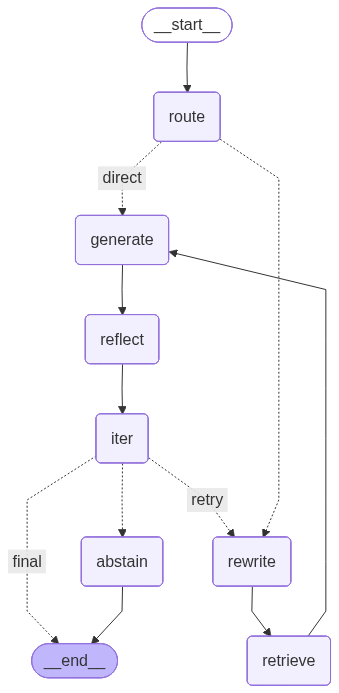

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END

class State(TypedDict):
    question: str
    rewritten: str
    tool: str
    domain: str
    k: int
    docs: List[Document]
    answer: str
    judge: dict
    iters: int
    max_iters: int

direct_prompt = ChatPromptTemplate.from_template("Responde breve y natural.\n\nPREGUNTA: {pregunta}")

final_prompt = ChatPromptTemplate.from_template(
    "Responde usando SOLO la OBSERVACIÓN.\n"
    "Si la OBSERVACIÓN no tiene la info, responde: 'No tengo esa información'.\n\n"
    "PREGUNTA: {pregunta}\n\n"
    "OBSERVACIÓN:\n{observacion}"
)

def node_route(state: State) -> State:
    decision = llm_route(state["question"])
    state["tool"] = (decision.get("tool","RETRIEVER") or "RETRIEVER").upper()
    state["domain"] = decision.get("args", {}).get("domain", "general")

    k, _ = choose_k_llm(state["question"])
    state["k"] = int(k)
    return state

def node_rewrite(state: State) -> State:
    state["rewritten"] = rewrite_query(state["question"])
    return state

def node_retrieve(state: State) -> State:
    q = state["rewritten"] or state["question"]
    state["docs"] = vs.similarity_search(q, k=int(state["k"]))
    return state

def node_generate(state: State) -> State:
    if state["tool"] == "DIRECT":
        state["answer"] = chat.invoke(direct_prompt.format_messages(pregunta=state["question"])).content
        return state
    obs = build_context(state.get("docs", []))
    state["answer"] = chat.invoke(final_prompt.format_messages(pregunta=state["question"], observacion=obs)).content
    return state

def node_reflect(state: State) -> State:
    if state["tool"] == "DIRECT":
        state["judge"] = {"groundedness":5,"completeness":5,"correctness":5,"clarity":5,"missing_info":[],"unsupported_claims":[],"conflicts_in_context":[]}
        return state
    state["judge"] = llm_judge(state["question"], state["answer"], state.get("docs", []))
    return state

def node_iter(state: State) -> State:
    state["iters"] = int(state.get("iters", 0)) + 1
    return state

def decide_after_route(state: State):
    return "direct" if state["tool"] == "DIRECT" else "rewrite"

def decide_after_iter(state: State):
    g = float(state.get("judge", {}).get("groundedness", 0))
    iters = int(state.get("iters", 0))
    max_iters = int(state.get("max_iters", 2))

    if g >= 4:
        return "final"
    if iters >= max_iters:
        return "abstain"
    return "retry"

def node_abstain(state: State) -> State:
    state["answer"] = "No tengo esa información."
    return state

graph = StateGraph(State)
graph.add_node("route", node_route)
graph.add_node("rewrite", node_rewrite)
graph.add_node("retrieve", node_retrieve)
graph.add_node("generate", node_generate)
graph.add_node("reflect", node_reflect)
graph.add_node("iter", node_iter)
graph.add_node("abstain", node_abstain)

graph.set_entry_point("route")
graph.add_conditional_edges("route", decide_after_route, {"direct":"generate","rewrite":"rewrite"})
graph.add_edge("rewrite","retrieve")
graph.add_edge("retrieve","generate")
graph.add_edge("generate","reflect")
graph.add_edge("reflect","iter")
graph.add_conditional_edges("iter", decide_after_iter, {"final":END,"retry":"rewrite","abstain":"abstain"})
graph.add_edge("abstain", END)

app = graph.compile()
app

### 🧩 Tu turno
Prueba el grafo con:
- una pregunta DIRECT
- una pregunta clara (de becas)
- una pregunta ambigua (retiros)
- una pregunta fuera de KB (homologación si no la agregaste)
y revisa: rewritten, k, judge.


In [ ]:
tests = [
    "Hola, ¿todo bien?",
    "¿Qué requisitos tiene una beca de mérito?",
    "¿hasta cuándo puedo retirar?",
    "¿Cuál es el costo de la homologación?"
]

for q in tests:
    out = app.invoke({
        "question": q,
        "rewritten": "",
        "tool": "",
        "domain": "",
        "k": 4,
        "docs": [],
        "answer": "",
        "judge": {},
        "iters": 0,
        "max_iters": 2,
    })
    print("\n=== Pregunta ===", q)
    print("Answer:", out["answer"])
    if out.get("tool") != "DIRECT":
        print("Rewritten:", out.get("rewritten"))
        print("k:", out.get("k"))
        print("Judge:", out.get("judge"))


### ❓ ¿Qué pasaría si…?
1) Si groundedness es bajo, ¿qué es más útil primero: rewrite o aumentar k? ¿por qué?  
2) ¿Por qué el budget evita que el sistema se “quede pensando” para siempre?  
3) En producción, ¿cuándo es mejor “No tengo esa información” que “lo más probable es que…”?
---